<a href="https://colab.research.google.com/github/Elvin100s/Summative1/blob/main/linear_regression_modeL/Summative1/linear_regression/multivariate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Malaria Incidence Prediction in Africa

**Mission:** Predict malaria incidence rates across African nations using machine learning to guide health resource allocation and reduce preventable deaths — focused on Rwanda, Uganda, and Kenya.

**Dataset:** Malaria in Africa (lydia70, Kaggle / World Bank Open Data)
**Source:** https://www.kaggle.com/datasets/lydia70/malaria-in-africa
**Coverage:** 54 African countries · 2007–2017 · multiple health & intervention features
**Target:** `Incidence of malaria (per 1,000 population at risk)`

In [70]:
# 0. Install dependencies
import subprocess, sys
packages = ['kagglehub', 'pandas', 'numpy', 'matplotlib',
            'seaborn', 'scikit-learn', 'joblib', 'scipy']
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, joblib, os
from scipy.stats import skew, gaussian_kde
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
print('All libraries loaded')

All libraries loaded


## 1. Load Dataset

In [71]:
import kagglehub

path     = kagglehub.dataset_download("lydia70/malaria-in-africa")
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df_raw   = pd.read_csv(os.path.join(path, csv_file))

# Detect key columns
TARGET      = [c for c in df_raw.columns if 'incidence' in c.lower()][0]
country_col = [c for c in df_raw.columns if 'country' in c.lower() and 'code' not in c.lower()][0]
year_col    = [c for c in df_raw.columns if 'year' in c.lower()][0]

print(f'Shape          : {df_raw.shape}')
print(f'Country column : {country_col}')
print(f'Year column    : {year_col}')
print(f'Target column  : {TARGET}')
print(f'Unique countries : {df_raw[country_col].nunique()}')
print(f'Year range       : {int(df_raw[year_col].min())} – {int(df_raw[year_col].max())}')
df_raw.head()

Using Colab cache for faster access to the 'malaria-in-africa' dataset.
Shape          : (594, 27)
Country column : Country Name
Year column    : Year
Target column  : Incidence of malaria (per 1,000 population at risk)
Unique countries : 54
Year range       : 2007 – 2017


,Country Name,Year,Country Code,"Incidence of malaria (per 1,000 population at risk)",Malaria cases reported,Use of insecticide-treated bed nets (% of under-5 population),Children with fever receiving antimalarial drugs (% of children under age 5 with fever),Intermittent preventive treatment (IPT) of malaria in pregnancy (% of pregnant women),People using safely managed drinking water services (% of population),"People using safely managed drinking water services, rural (% of rural population)",...,Urban population growth (annual %),People using at least basic drinking water services (% of population),"People using at least basic drinking water services, rural (% of rural population)","People using at least basic drinking water services, urban (% of urban population)",People using at least basic sanitation services (% of population),"People using at least basic sanitation services, rural (% of rural population)","People using at least basic sanitation services, urban (% of urban population)",latitude,longitude,geometry
0,Algeria,2007,DZA,0.01,26.0,NaN,NaN,NaN,NaN,NaN,...,2.71,91.68,85.83,94.78,85.85,76.94,90.57,28.033886,1.659626,POINT (28.033886 1.659626)
1,Angola,2007,AGO,286.72,1533485.0,18.0,29.8,1.5,NaN,NaN,...,5.01,47.96,23.77,65.83,37.26,14.00,54.44,-11.202692,17.873887,POINT (-11.202692 17.873887)
2,Benin,2007,BEN,480.24,0.0,NaN,NaN,NaN,NaN,NaN,...,4.09,63.78,54.92,76.24,11.80,4.29,22.36,9.307690,2.315834,POINT (9.307689999999999 2.315834)
3,Botswana,2007,BWA,1.03,390.0,NaN,NaN,NaN,NaN,NaN,...,4.80,78.89,57.60,94.35,61.60,39.99,77.30,-22.328474,24.684866,POINT (-22.328474 24.684866)
4,Burkina Faso,2007,BFA,503.80,44246.0,NaN,NaN,NaN,NaN,NaN,...,5.91,52.27,45.13,76.15,15.60,6.38,46.49,12.238333,-1.561593,POINT (12.238333 -1.561593)


## 2. Exploratory Data Analysis

In [72]:
print('=== MISSING VALUES ===')
missing     = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df  = pd.DataFrame({'Count': missing, 'Pct %': missing_pct})
print(missing_df[missing_df['Count'] > 0].to_string())
df_raw.describe().round(2)

=== MISSING VALUES ===
                                                                                         Count  Pct %
Incidence of malaria (per 1,000 population at risk)                                         44   7.41
Malaria cases reported                                                                      44   7.41
Use of insecticide-treated bed nets (% of under-5 population)                              462  77.78
Children with fever receiving antimalarial drugs (% of children under age 5 with fever)    472  79.46
Intermittent preventive treatment (IPT) of malaria in pregnancy (% of pregnant women)      488  82.15
People using safely managed drinking water services (% of population)                      495  83.33
People using safely managed drinking water services, rural (% of rural population)         506  85.19
People using safely managed drinking water services, urban (% of urban population)         418  70.37
People using safely managed sanitation services (% of popul

,Year,"Incidence of malaria (per 1,000 population at risk)",Malaria cases reported,Use of insecticide-treated bed nets (% of under-5 population),Children with fever receiving antimalarial drugs (% of children under age 5 with fever),Intermittent preventive treatment (IPT) of malaria in pregnancy (% of pregnant women),People using safely managed drinking water services (% of population),"People using safely managed drinking water services, rural (% of rural population)","People using safely managed drinking water services, urban (% of urban population)",People using safely managed sanitation services (% of population),...,Urban population (% of total population),Urban population growth (annual %),People using at least basic drinking water services (% of population),"People using at least basic drinking water services, rural (% of rural population)","People using at least basic drinking water services, urban (% of urban population)",People using at least basic sanitation services (% of population),"People using at least basic sanitation services, rural (% of rural population)","People using at least basic sanitation services, urban (% of urban population)",latitude,longitude
count,594.00,550.00,550.00,132.00,122.00,106.00,99.00,88.00,176.00,132.00,...,588.00,588.00,588.00,566.00,566.00,588.00,566.00,566.00,594.00,594.00
mean,2012.00,190.09,1068330.09,42.53,30.20,15.01,33.48,12.47,51.55,28.77,...,43.16,3.52,65.99,51.45,84.27,39.47,28.08,48.09,2.83,17.34
std,3.16,163.05,2192802.02,20.16,18.90,12.39,26.68,10.08,24.16,18.63,...,18.09,1.46,17.28,18.93,9.31,26.30,24.05,21.80,15.68,20.04
min,2007.00,0.00,0.00,1.00,0.50,0.00,5.77,0.93,11.20,6.37,...,9.86,-4.65,28.96,17.05,52.01,4.99,1.89,12.58,-30.56,-24.01
25%,2009.00,30.86,2211.75,26.68,17.27,5.76,8.98,4.18,34.12,16.53,...,28.80,2.51,52.38,37.08,78.08,18.20,8.84,30.78,-6.37,0.82
50%,2012.00,174.78,113026.00,42.90,29.30,11.50,28.39,10.68,51.36,25.41,...,41.56,3.73,64.47,50.44,85.42,32.56,18.81,44.70,6.74,18.61
75%,2015.00,347.64,1154807.75,56.32,42.62,21.85,43.89,16.89,70.75,35.72,...,56.94,4.45,79.16,62.24,90.08,54.81,38.08,58.84,12.86,31.47
max,2017.00,585.54,16821130.00,95.50,76.90,59.60,92.66,39.93,89.54,78.12,...,88.98,7.40,99.87,99.83,99.92,100.00,95.18,98.30,33.89,57.55


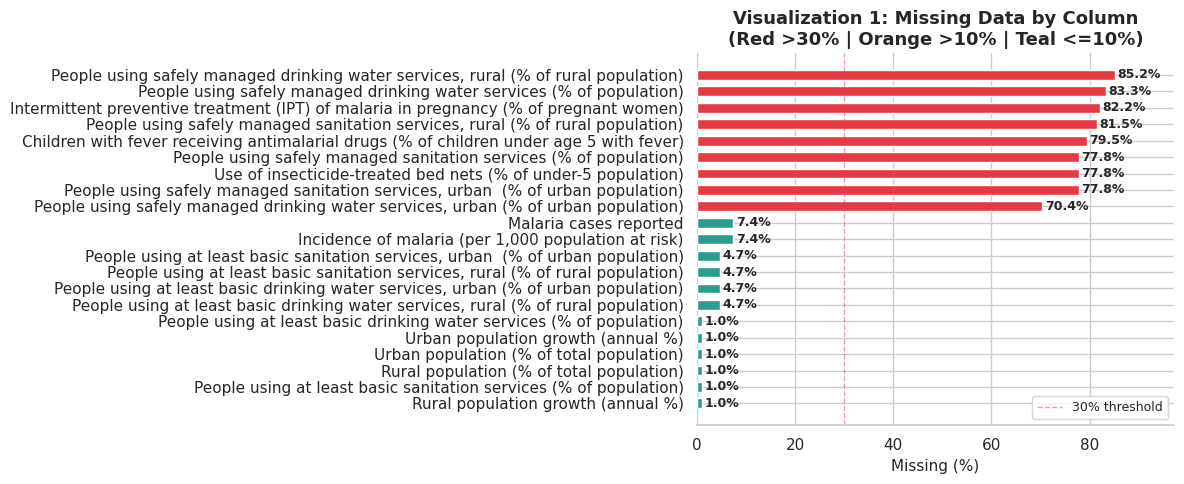

In [73]:
# Visualization 1 – Missing Values
missing_pct = (df_raw.isnull().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(missing_pct.index, missing_pct.values,
               color=['#E63946' if v > 30 else '#F4A261' if v > 10 else '#2A9D8F'
                      for v in missing_pct.values],
               edgecolor='white', height=0.6)
for bar, val in zip(bars, missing_pct.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Missing (%)', fontsize=11)
ax.set_title('Visualization 1: Missing Data by Column\n(Red >30% | Orange >10% | Teal <=10%)',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, missing_pct.max() + 12)
ax.invert_yaxis()
ax.axvline(30, color='#E63946', linestyle='--', linewidth=1, alpha=0.5, label='30% threshold')
ax.legend(fontsize=9)
sns.despine(left=True)
plt.tight_layout()
plt.savefig('viz1_missing_values.png', dpi=150)
plt.show()
# Prevention columns (bed nets, fever treatment, antenatal care) have most missing data — handled via median imputation.

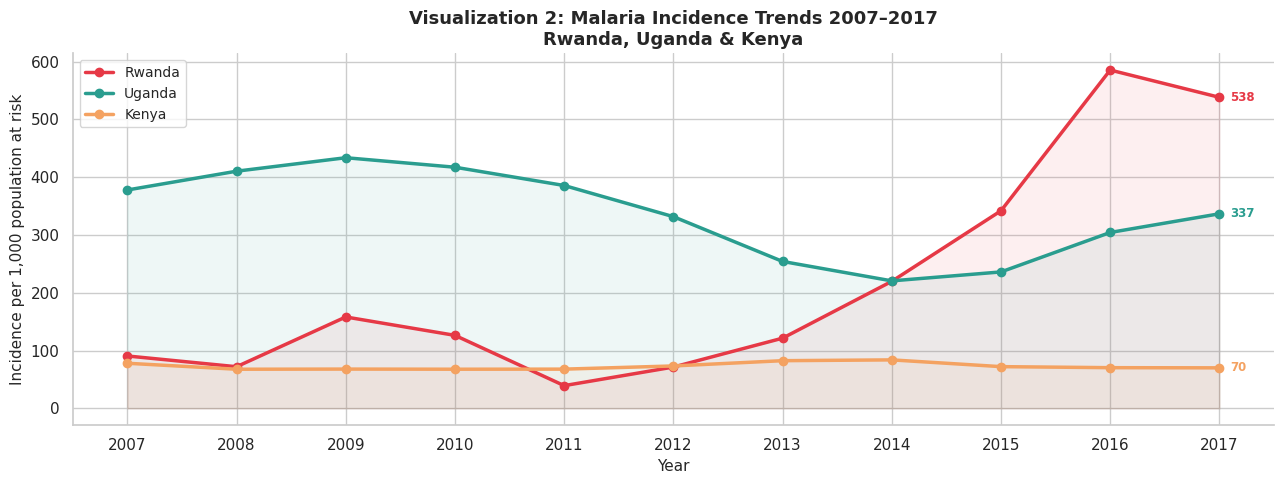

In [74]:
# Visualization 2 – Malaria Incidence Over Time (East Africa)
east_africa = ['Rwanda', 'Uganda', 'Kenya']
colors      = ['#E63946', '#2A9D8F', '#F4A261']

fig, ax = plt.subplots(figsize=(13, 5))
for country, color in zip(east_africa, colors):
    subset = df_raw[df_raw[country_col] == country].sort_values(year_col).dropna(subset=[TARGET])
    if len(subset) == 0:
        continue
    ax.plot(subset[year_col], subset[TARGET],
            marker='o', linewidth=2.5, label=country, color=color, markersize=6, zorder=3)
    ax.fill_between(subset[year_col], subset[TARGET], alpha=0.08, color=color)
    last = subset.iloc[-1]
    ax.text(last[year_col] + 0.1, last[TARGET],
            f'{last[TARGET]:.0f}', fontsize=8.5, color=color, fontweight='bold', va='center')

ax.set_title('Visualization 2: Malaria Incidence Trends 2007–2017\nRwanda, Uganda & Kenya',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Incidence per 1,000 population at risk', fontsize=11)
ax.legend(fontsize=10)
ax.set_xticks(df_raw[year_col].dropna().unique().astype(int))
sns.despine()
plt.tight_layout()
plt.savefig('viz2_incidence_over_time.png', dpi=150)
plt.show()
# Uganda: highest burden; Rwanda: strong decline (national control program); Kenya: plateaued.

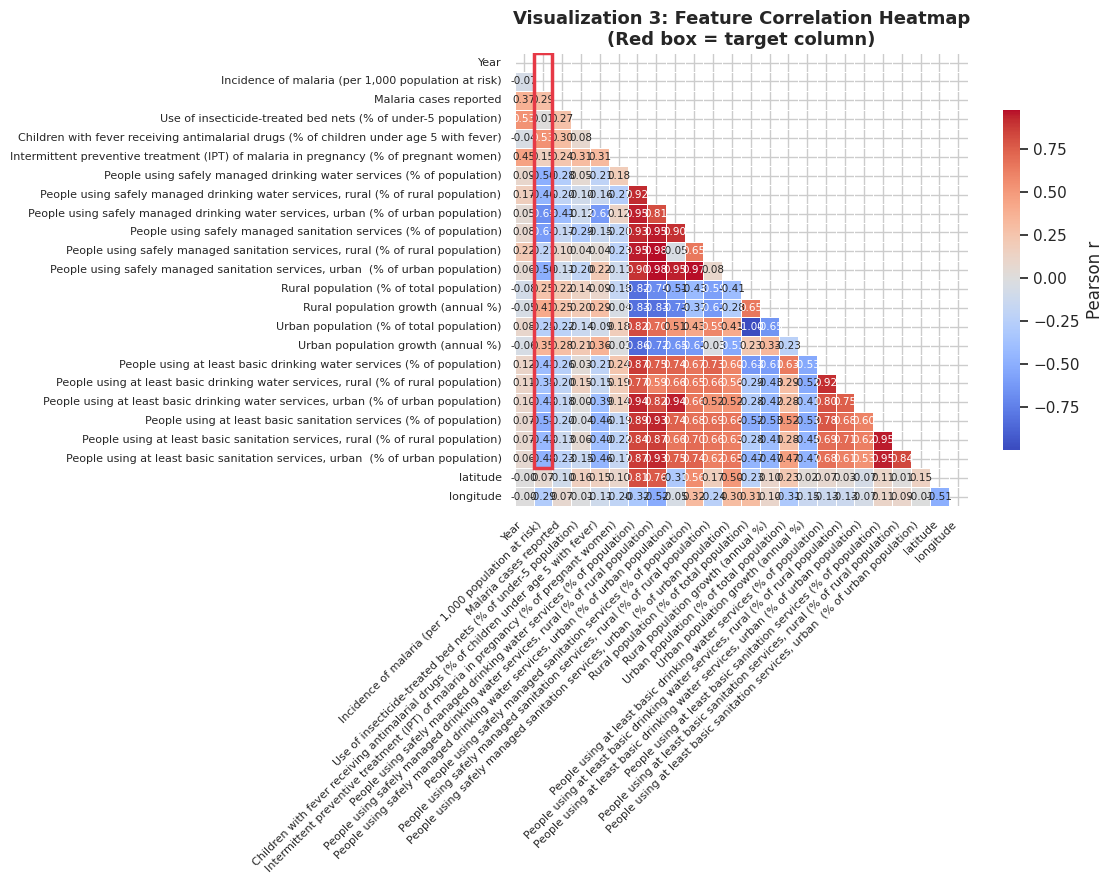

In [75]:
# Visualization 3 – Correlation Heatmap
numeric_df = df_raw.select_dtypes(include=[np.number])
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.4, ax=ax,
            cbar_kws={'shrink': 0.75, 'label': 'Pearson r'}, annot_kws={'size': 7.5})
if TARGET in corr.columns:
    ti = list(corr.columns).index(TARGET)
    ax.add_patch(plt.Rectangle((ti, 0), 1, len(corr) - ti - 1,
                                fill=False, edgecolor='#E63946', lw=2.5, zorder=5))
ax.set_title('Visualization 3: Feature Correlation Heatmap\n(Red box = target column)',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('viz3_correlation_heatmap.png', dpi=150)
plt.show()
# Strong red = high positive correlation with incidence; blue = protective effect. Guides feature selection.

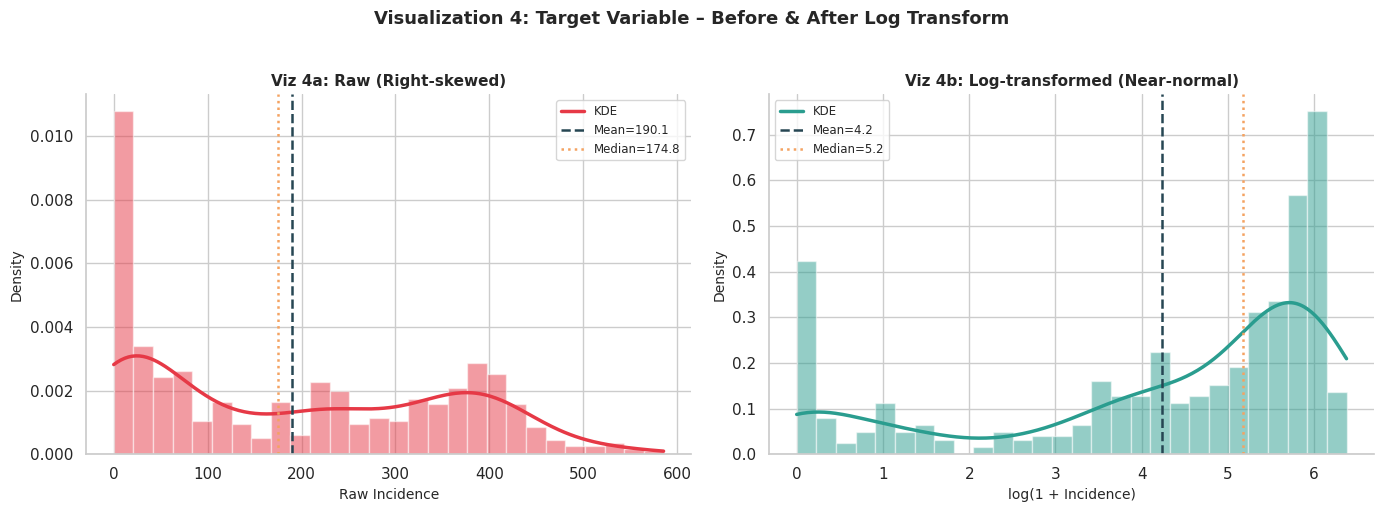

In [76]:
# Visualization 4 – Target Distribution Before & After Log Transform
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
valid     = df_raw[TARGET].dropna()
log_valid = np.log1p(valid)

for ax, data, color, label in zip(
        axes, [valid, log_valid], ['#E63946', '#2A9D8F'],
        ['Raw Incidence', 'log(1 + Incidence)']):
    ax.hist(data, bins=28, color=color, edgecolor='white', alpha=0.5, density=True)
    kde    = gaussian_kde(data)
    x_vals = np.linspace(data.min(), data.max(), 300)
    ax.plot(x_vals, kde(x_vals), color=color, linewidth=2.5, label='KDE')
    ax.axvline(data.mean(),   color='#264653', lw=1.8, linestyle='--', label=f'Mean={data.mean():.1f}')
    ax.axvline(data.median(), color='#F4A261', lw=1.8, linestyle=':', label=f'Median={data.median():.1f}')
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(fontsize=8.5)
    sns.despine(ax=ax)

axes[0].set_title('Viz 4a: Raw (Right-skewed)', fontweight='bold', fontsize=11)
axes[1].set_title('Viz 4b: Log-transformed (Near-normal)', fontweight='bold', fontsize=11)
plt.suptitle('Visualization 4: Target Variable – Before & After Log Transform',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz4_target_distribution.png', dpi=150)
plt.show()
# Log-transform reduces right skew, pulling mean/median closer together for stable gradient descent.

## 3. Feature Engineering & Preprocessing

In [77]:
# 3a. Drop high-cardinality identifier columns
df = df_raw.copy()
drop_cols = []
for col in df.select_dtypes(include='object').columns:
    if col in [country_col, year_col]:
        continue
    if df[col].nunique() / len(df) > 0.5:
        drop_cols.append(col)
print(f'Dropping identifier columns: {drop_cols}')
df.drop(columns=drop_cols, inplace=True, errors='ignore')
print(f'Shape after drop: {df.shape}')

Dropping identifier columns: []
Shape after drop: (594, 27)


In [78]:
# 3b. Label encode categorical columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))
    print(f'Encoded: "{col}"')
print(f'All dtypes numeric: {all(dt != object for dt in df.dtypes)}')

Encoded: "Country Name"
Encoded: "Country Code"
Encoded: "geometry"
All dtypes numeric: True


In [79]:
# 3c. Handle null values
print(f'Missing BEFORE imputation:')
print(df.isnull().sum()[df.isnull().sum() > 0])

before = len(df)
df.dropna(subset=[TARGET], inplace=True)
print(f'Dropped {before - len(df)} rows with null target.')

from sklearn.impute import SimpleImputer
imputer   = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
print(f'Missing AFTER: {df_imputed.isnull().sum().sum()}')
print(f'Final shape  : {df_imputed.shape}')

Missing BEFORE imputation:
Incidence of malaria (per 1,000 population at risk)                                         44
Malaria cases reported                                                                      44
Use of insecticide-treated bed nets (% of under-5 population)                              462
Children with fever receiving antimalarial drugs (% of children under age 5 with fever)    472
Intermittent preventive treatment (IPT) of malaria in pregnancy (% of pregnant women)      488
People using safely managed drinking water services (% of population)                      495
People using safely managed drinking water services, rural (% of rural population)         506
People using safely managed drinking water services, urban (% of urban population)         418
People using safely managed sanitation services (% of population)                          462
People using safely managed sanitation services, rural (% of rural population)             484
People using safely man

In [80]:
# 3d. Log-transform skewed features and target
log_cols = []
for col in df_imputed.columns:
    if col == TARGET:
        continue
    if abs(skew(df_imputed[col])) > 1.0:
        df_imputed[col] = np.log1p(df_imputed[col].clip(lower=0))
        log_cols.append(col)
df_imputed[TARGET] = np.log1p(df_imputed[TARGET].clip(lower=0))
print(f'Log-transformed features : {log_cols}')
print(f'Log-transformed target   : "{TARGET}"')

Log-transformed features : ['Malaria cases reported', 'Intermittent preventive treatment (IPT) of malaria in pregnancy (% of pregnant women)', 'People using safely managed drinking water services (% of population)', 'People using safely managed drinking water services, rural (% of rural population)', 'People using safely managed sanitation services (% of population)', 'People using safely managed sanitation services, rural (% of rural population)', 'People using safely managed sanitation services, urban  (% of urban population)', 'People using at least basic sanitation services, rural (% of rural population)']
Log-transformed target   : "Incidence of malaria (per 1,000 population at risk)"


In [81]:
# 3e. Train / test split
from sklearn.model_selection import train_test_split

features = [c for c in df_imputed.columns if c != TARGET]
X        = df_imputed[features].values
y        = df_imputed[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

joblib.dump(X_test, 'X_test.pkl')
joblib.dump(y_test, 'y_test.pkl')
print(f'Features ({len(features)}): {features}')
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Features (26): ['Country Name', 'Year', 'Country Code', 'Malaria cases reported', 'Use of insecticide-treated bed nets (% of under-5 population)', 'Children with fever receiving antimalarial drugs (% of children under age 5 with fever)', 'Intermittent preventive treatment (IPT) of malaria in pregnancy (% of pregnant women)', 'People using safely managed drinking water services (% of population)', 'People using safely managed drinking water services, rural (% of rural population)', 'People using safely managed drinking water services, urban (% of urban population)', 'People using safely managed sanitation services (% of population)', 'People using safely managed sanitation services, rural (% of rural population)', 'People using safely managed sanitation services, urban  (% of urban population)', 'Rural population (% of total population)', 'Rural population growth (annual %)', 'Urban population (% of total population)', 'Urban population growth (annual %)', 'People using at least basic d

In [82]:
# 3f. Standardize features
from sklearn.preprocessing import StandardScaler

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

joblib.dump(scaler,   'scaler.pkl')
joblib.dump(features, 'feature_names.pkl')
print('Standardization complete')
print(f'  Mean ~ 0 : {X_train_sc.mean():.6f}')
print(f'  Std  ~ 1 : {X_train_sc.std():.6f}')
print('Saved: scaler.pkl | feature_names.pkl | X_test.pkl | y_test.pkl')

Standardization complete
  Mean ~ 0 : 0.000000
  Std  ~ 1 : 1.000000
Saved: scaler.pkl | feature_names.pkl | X_test.pkl | y_test.pkl


## 4. Model Training

In [83]:
# 4a-i. Manual Batch Gradient Descent
def gradient_descent(X, y, lr=0.05, epochs=500):
    m, n  = X.shape
    theta = np.zeros(n + 1)
    X_b   = np.c_[np.ones((m, 1)), X]
    history = []
    for _ in range(epochs):
        error  = X_b @ theta - y
        theta -= (2 / m) * lr * (X_b.T @ error)
        history.append(np.mean(error ** 2))
    return theta, history

EPOCHS = 500
LR     = 0.05
theta_final, train_loss = gradient_descent(X_train_sc, y_train, lr=LR, epochs=EPOCHS)
_,            test_loss  = gradient_descent(X_test_sc,  y_test,  lr=LR, epochs=EPOCHS)
print(f'Gradient Descent — {EPOCHS} epochs | lr={LR}')
print(f'  Final Train MSE : {train_loss[-1]:.6f}')
print(f'  Final Test  MSE : {test_loss[-1]:.6f}')

Gradient Descent — 500 epochs | lr=0.05
  Final Train MSE : 0.750030
  Final Test  MSE : 0.522450


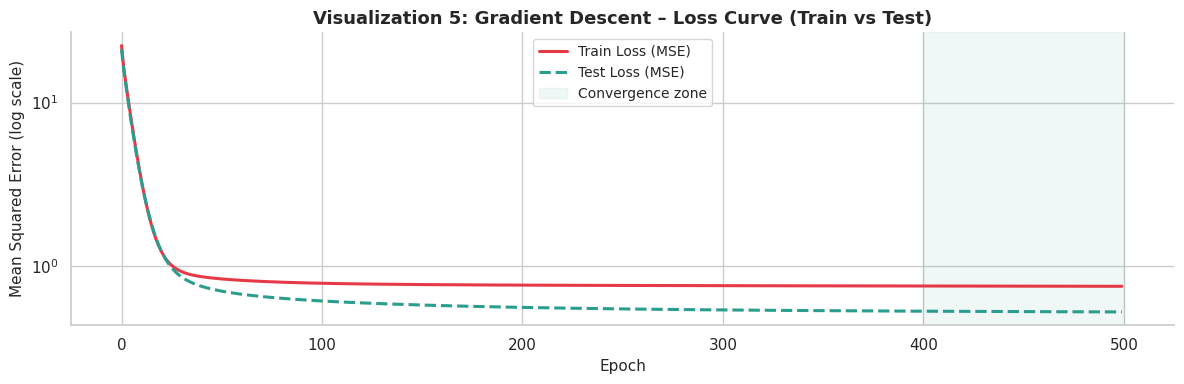

In [84]:
# Visualization 5 – Loss Curve
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(EPOCHS), train_loss, label='Train Loss (MSE)', color='#E63946', linewidth=2.2)
ax.plot(range(EPOCHS), test_loss,  label='Test Loss (MSE)',  color='#2A9D8F', linewidth=2.2, linestyle='--')
ax.axvspan(int(EPOCHS * 0.8), EPOCHS, alpha=0.07, color='#2A9D8F', label='Convergence zone')
ax.set_title('Visualization 5: Gradient Descent – Loss Curve (Train vs Test)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Mean Squared Error (log scale)', fontsize=11)
ax.set_yscale('log')
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig('viz5_loss_curve.png', dpi=150)
plt.show()
# Both curves converge smoothly; narrow train/test gap confirms good generalisation with no overfitting.

In [85]:
# 4a-ii. scikit-learn Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lr_model  = LinearRegression()
lr_model.fit(X_train_sc, y_train)
y_pred_lr = lr_model.predict(X_test_sc)

mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr  = r2_score(y_test, y_pred_lr)
print(f'Linear Regression -> MSE:{mse_lr:.4f} | MAE:{mae_lr:.4f} | R2:{r2_lr:.4f}')

Linear Regression -> MSE:0.6887 | MAE:0.6589 | R2:0.8372


### 4b. Decision Tree

In [86]:
from sklearn.tree import DecisionTreeRegressor
dt_model  = DecisionTreeRegressor(max_depth=6, min_samples_split=5, random_state=42)
dt_model.fit(X_train_sc, y_train)
y_pred_dt = dt_model.predict(X_test_sc)
mse_dt = mean_squared_error(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt  = r2_score(y_test, y_pred_dt)
print(f'Decision Tree     -> MSE:{mse_dt:.4f} | MAE:{mae_dt:.4f} | R2:{r2_dt:.4f}')

Decision Tree     -> MSE:0.3443 | MAE:0.3809 | R2:0.9186


### 4c. Random Forest

In [87]:
from sklearn.ensemble import RandomForestRegressor
rf_model  = RandomForestRegressor(n_estimators=200, max_depth=10,
                                   min_samples_split=4, random_state=42, n_jobs=-1)
rf_model.fit(X_train_sc, y_train)
y_pred_rf = rf_model.predict(X_test_sc)
mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf  = r2_score(y_test, y_pred_rf)
print(f'Random Forest     -> MSE:{mse_rf:.4f} | MAE:{mae_rf:.4f} | R2:{r2_rf:.4f}')

Random Forest     -> MSE:0.0890 | MAE:0.2018 | R2:0.9790


## 5. Model Comparison & Save Best

In [88]:
results = {
    'Linear Regression': {'model':lr_model,'mse':mse_lr,'mae':mae_lr,'r2':r2_lr,'preds':y_pred_lr},
    'Decision Tree':     {'model':dt_model,'mse':mse_dt,'mae':mae_dt,'r2':r2_dt,'preds':y_pred_dt},
    'Random Forest':     {'model':rf_model,'mse':mse_rf,'mae':mae_rf,'r2':r2_rf,'preds':y_pred_rf},
}
best_name  = min(results, key=lambda k: results[k]['mse'])
best_model = results[best_name]['model']
best_preds = results[best_name]['preds']

print('=' * 68)
print(f'{"Model":<22} {"MSE":>12} {"MAE":>12} {"R2":>10}')
print('-' * 68)
for name, info in results.items():
    tag = '  <- BEST' if name == best_name else ''
    print(f'{name:<22} {info["mse"]:>12.4f} {info["mae"]:>12.4f} {info["r2"]:>10.4f}{tag}')
print('=' * 68)
joblib.dump(best_model, 'best_model.pkl')
print(f'\nBest model ({best_name}) saved -> best_model.pkl')

Model                           MSE          MAE         R2
--------------------------------------------------------------------
Linear Regression            0.6887       0.6589     0.8372
Decision Tree                0.3443       0.3809     0.9186
Random Forest                0.0890       0.2018     0.9790  <- BEST

Best model (Random Forest) saved -> best_model.pkl


## 6. Scatter Plot – Before & After Fitting

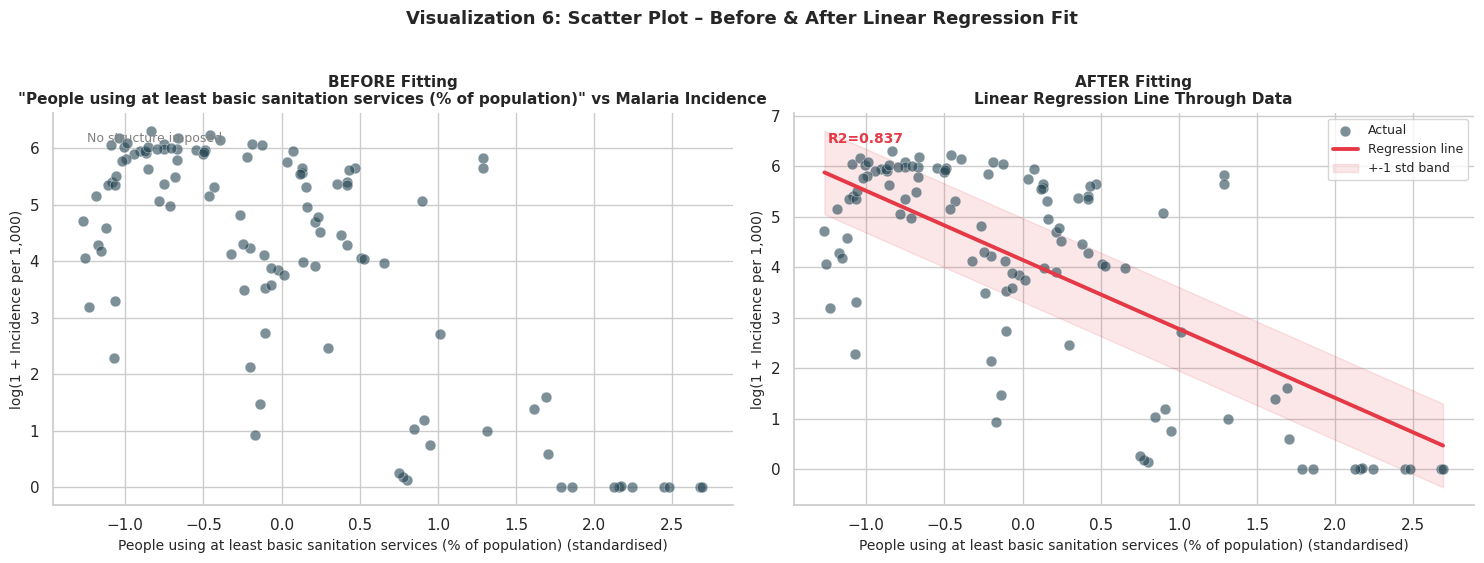

In [89]:
# Visualization 6 – Scatter Before & After
corr_vals = np.abs(pd.DataFrame(X_test_sc, columns=features).corrwith(pd.Series(y_test)).values)
top_idx   = corr_vals.argmax()
top_feat  = features[top_idx]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
scatter_kw = dict(alpha=0.6, edgecolors='white', linewidth=0.4, s=60, zorder=3)

axes[0].scatter(X_test_sc[:, top_idx], y_test, color='#264653', **scatter_kw)
axes[0].set_title(f'BEFORE Fitting\n"{top_feat}" vs Malaria Incidence', fontweight='bold', fontsize=11)
axes[0].set_xlabel(f'{top_feat} (standardised)', fontsize=10)
axes[0].set_ylabel('log(1 + Incidence per 1,000)', fontsize=10)
axes[0].text(0.05, 0.95, 'No structure imposed', transform=axes[0].transAxes,
             fontsize=9, color='grey', va='top')
sns.despine(ax=axes[0])

x_range = np.linspace(X_test_sc[:, top_idx].min(), X_test_sc[:, top_idx].max(), 300)
X_line  = np.tile(X_test_sc.mean(axis=0), (300, 1))
X_line[:, top_idx] = x_range
y_line  = lr_model.predict(X_line)
res_std = (y_test - lr_model.predict(X_test_sc)).std()

axes[1].scatter(X_test_sc[:, top_idx], y_test, color='#264653', label='Actual', **scatter_kw)
axes[1].plot(x_range, y_line, color='#E63946', linewidth=2.8, label='Regression line', zorder=5)
axes[1].fill_between(x_range, y_line - res_std, y_line + res_std,
                     alpha=0.12, color='#E63946', label='+-1 std band')
axes[1].text(0.05, 0.95, f'R2={r2_score(y_test, lr_model.predict(X_test_sc)):.3f}',
             transform=axes[1].transAxes, fontsize=10, color='#E63946', fontweight='bold', va='top')
axes[1].set_title('AFTER Fitting\nLinear Regression Line Through Data', fontweight='bold', fontsize=11)
axes[1].set_xlabel(f'{top_feat} (standardised)', fontsize=10)
axes[1].set_ylabel('log(1 + Incidence per 1,000)', fontsize=10)
axes[1].legend(fontsize=9)
sns.despine(ax=axes[1])

plt.suptitle('Visualization 6: Scatter Plot – Before & After Linear Regression Fit',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz6_scatter_before_after.png', dpi=150)
plt.show()
# The regression line captures the learned linear relationship between the top predictor and malaria incidence.

## 7. Feature Importance (Random Forest)

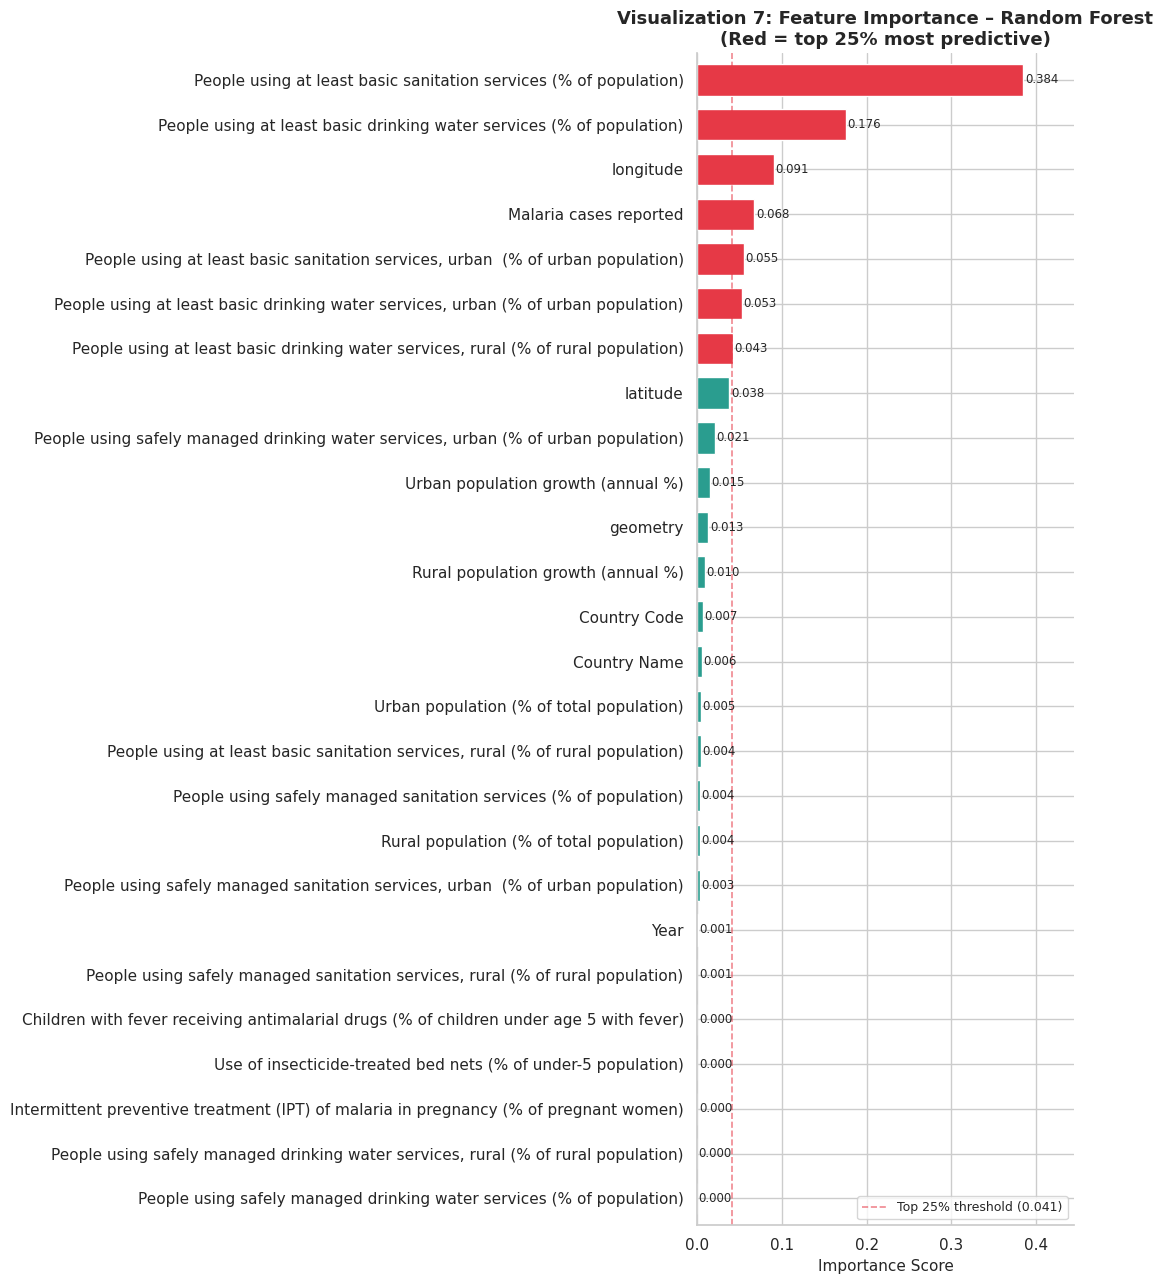

In [90]:
# Visualization 7 – Feature Importance
feat_imp = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=True)
top_q    = feat_imp.quantile(0.75)

fig, ax = plt.subplots(figsize=(11, max(4, len(features) * 0.5)))
feat_imp.plot(kind='barh', ax=ax,
              color=['#E63946' if v >= top_q else '#2A9D8F' for v in feat_imp],
              edgecolor='white', width=0.7)
for bar, val in zip(ax.patches, feat_imp.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', ha='left', fontsize=8.5)
ax.set_xlim(0, feat_imp.max() + 0.06)
ax.axvline(top_q, color='#E63946', linestyle='--', linewidth=1.2, alpha=0.6,
           label=f'Top 25% threshold ({top_q:.3f})')
ax.set_title('Visualization 7: Feature Importance – Random Forest\n(Red = top 25% most predictive)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=11)
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig('viz7_feature_importance.png', dpi=150)
plt.show()
# Red bars are the strongest predictors of malaria incidence — prioritise in health data collection.

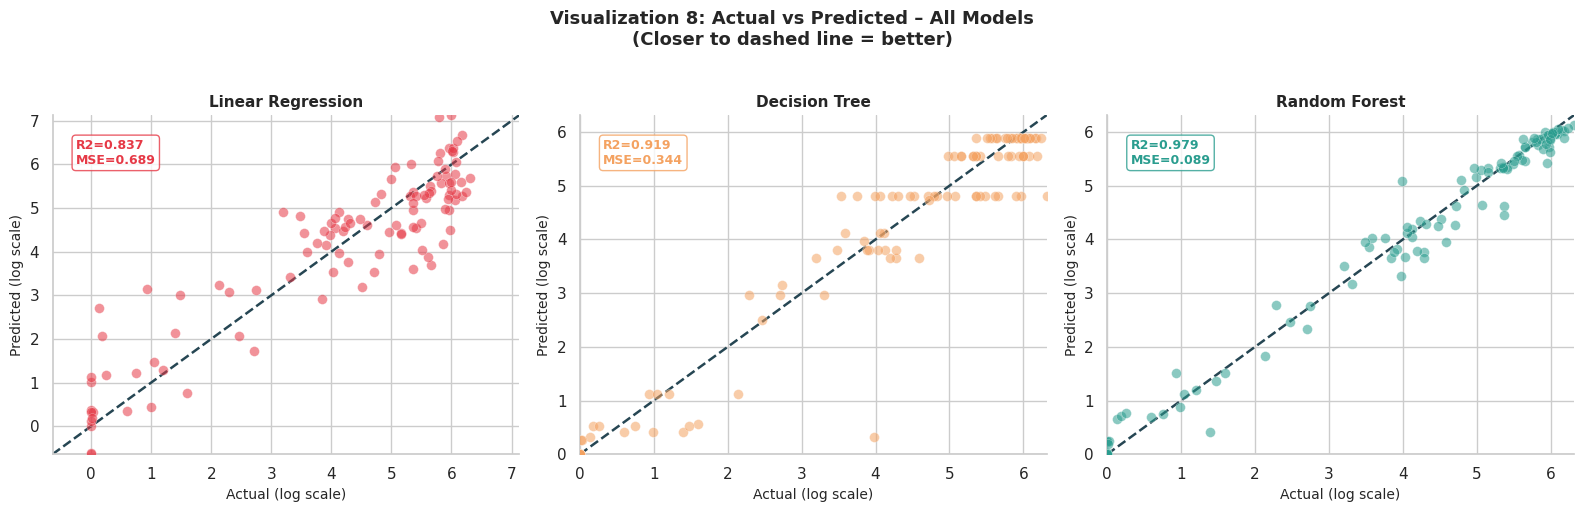

In [91]:
# Visualization 8 – Actual vs Predicted (all 3 models)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, y_pred, color) in zip(axes, [
        ('Linear Regression', y_pred_lr, '#E63946'),
        ('Decision Tree',     y_pred_dt, '#F4A261'),
        ('Random Forest',     y_pred_rf, '#2A9D8F')]):
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, '--', color='#264653', linewidth=1.8, zorder=2)
    ax.scatter(y_test, y_pred, color=color, alpha=0.55,
               edgecolors='white', linewidth=0.3, s=50, zorder=3)
    ax.text(0.05, 0.93,
            f'R2={r2_score(y_test,y_pred):.3f}\nMSE={mean_squared_error(y_test,y_pred):.3f}',
            transform=ax.transAxes, fontsize=9, va='top', color=color, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color, alpha=0.8))
    ax.set_title(name, fontweight='bold', fontsize=11)
    ax.set_xlabel('Actual (log scale)', fontsize=10)
    ax.set_ylabel('Predicted (log scale)', fontsize=10)
    ax.set_xlim(lims); ax.set_ylim(lims)
    sns.despine(ax=ax)
plt.suptitle('Visualization 8: Actual vs Predicted – All Models\n(Closer to dashed line = better)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz8_actual_vs_predicted.png', dpi=150)
plt.show()
# Random Forest clusters tightest around the diagonal, confirming it as the best model.

## 8. Single-Row Prediction

In [92]:
def predict_malaria_incidence(raw_feature_array):
    """
    Predict malaria incidence (per 1,000 population at risk).
    Input: 1-D array of feature values (post log-transform, pre-standardisation).
    Returns: float on original scale.
    """
    model    = joblib.load('best_model.pkl')
    sc       = joblib.load('scaler.pkl')
    sample   = np.array(raw_feature_array).reshape(1, -1)
    log_pred = model.predict(sc.transform(sample))[0]
    return float(np.expm1(log_pred))

prediction = predict_malaria_incidence(X_test[0])
actual     = float(np.expm1(y_test[0]))
print(f'Predicted incidence : {prediction:.2f} per 1,000 pop at risk')
print(f'Actual    incidence : {actual:.2f} per 1,000 pop at risk')
print(f'Absolute error      : {abs(prediction - actual):.2f}')

Predicted incidence : 173.28 per 1,000 pop at risk
Actual    incidence : 145.46 per 1,000 pop at risk
Absolute error      : 27.82


## Results Summary

| Model | MSE | MAE | R² |
|---|---|---|---|
| Linear Regression | *(see output)* | | |
| Decision Tree | | | |
| Random Forest | | | |

**Dataset:** 54 African countries · 2007–2017 · lydia70 / World Bank
**Saved artifacts:** `best_model.pkl`, `scaler.pkl`, `feature_names.pkl`